# **Atividade Prática**
<font size=3>

- **Tema:** métodos baseados em árvores.
- **Prazo de entrega:** 14 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

### **1. Questão:**
<font size=3>

Com base no *dataset* de [classificação de dígitos](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), realize os seguintes passos:

1. **Importe os dados** nas variáveis de atributos (`X`) e alvo (`y`). Este *dataset* apresenta imagens de dígitos manuscritos em formato de *arrays* unidimensionais e suas "etiquetas" como números interios de 0 a 9;  

2. **Escreva** em uma **cálula _markdown_** do que se tratam os atributos dos dados de entrada;

3. Plote a imagem de um dígitos utilizando a função [`imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html). Aqui será necessário fazer o *reshape* da imagem $(64,)$ para $(8\times 8)$;

4. Para o modelo [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) se faz necessário pré-processamento dos dados de entrada e alvo? **Justifique sua resposta** em uma **cálula _markdown_**.

5. Treine este modelo, utilizando o [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) para afinar os hyperparâmetros de poda. **Imprima na tela** os melhores valores de hiperparâmetros;

5. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. Existem características em comuns nos dois dígitos de melhor classificação? **Justifique sua resposta** em uma **cálula _markdown_**.


In [27]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [28]:
dataset = load_digits()

In [29]:
X = dataset.data
y = dataset.target
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1797, 64)
Formato de y: (1797,)


(1797, 64)
(8, 8)


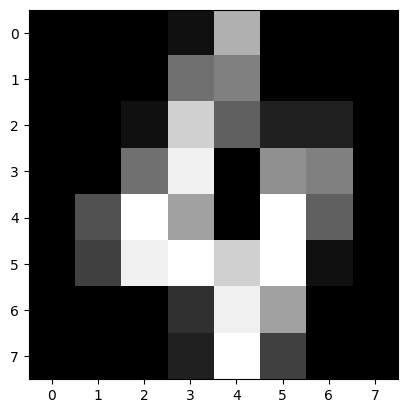

In [30]:
print(dataset.data.shape)
imagem = dataset.images[4]
imagem_reshape = imagem.reshape(8, 8)
print(imagem_reshape.shape)
plt.imshow(imagem_reshape, cmap="gray")
plt.show()


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


Para o DecisionTreeClassifier normalmente não é necessário fazer pré-processamento dos dados numéricos de entrada nem do alvo, uma vez que a árvore de decisão trabalha dividindo os dados por regras, não depende de distância entre pontos, não é sensível à escala dos atributos e não exige normalização ou padronização.

In [32]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [33]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'ccp_alpha': [0.0, 0.0001, 0.001, 0.01]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
)

grid.fit(X_train, y_train)

print("Melhores valores de hiperparâmetros:", grid.best_params_)

Melhores valores de hiperparâmetros: {'ccp_alpha': 0.001, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [34]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

# precision e recall mostram qualidade proporcional da classificação

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.83      0.76      0.79        50
           2       0.73      0.74      0.74        47
           3       0.73      0.89      0.80        54
           4       0.82      0.85      0.84        60
           5       0.95      0.82      0.88        66
           6       0.89      0.96      0.93        53
           7       0.88      0.84      0.86        55
           8       0.81      0.91      0.86        43
           9       0.82      0.80      0.81        59

    accuracy                           0.84       540
   macro avg       0.85      0.85      0.84       540
weighted avg       0.85      0.84      0.85       540

Matriz de confusão:
 [[47  0  2  0  0  2  1  0  1  0]
 [ 0 38  6  0  2  0  0  1  1  2]
 [ 0  2 35  3  1  0  1  1  3  1]
 [ 0  1  0 48  1  0  0  0  1  3]
 [ 0  3  0  1 51  0  2  1  0  2]
 [ 0  0  4  3  3 54  2  0  0  0]
 [ 0  0  0  0  1  0 51

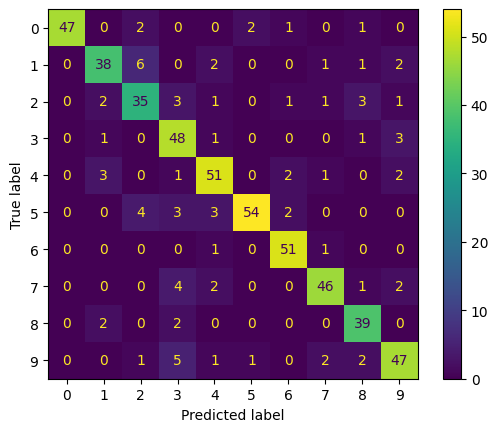

In [35]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# a diagonal mostra quantidade bruta de acertos

Os dois dígitos de melhor classificação possuem características visuais mais diferentes em relação aos outros números do dataset. Dígitos como 0 e 6, ou 5 e 6, possuem formatos bem definidos e pouca semelhança com outras classes. O 0 possui um formato fechado característico e o 6 apresenta uma curva interna bem marcada. Essas propriedades facilitam a separação realizada pela árvore de decisão, reduzindo confusões entre classes. Além disso, esses dígitos costumam ter menor variação na escrita manual em diferentes amostras, o que contribui para valores elevados de precision, recall e f1-score.

### **2. Questão:**
<font size=3>

Com base no *dataset* de [Classificação de Poemas](https://www.kaggle.com/datasets/ramjasmaurya/poem-classification-nlp), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:

1. Importe o *dataset* e defina os poemas como a variável de atributos e os gêneros como a variável alvo;

2. Utilize a função [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) para quebrar os poemas em listas de palavras, e transformar estas em representações numéricos, considerando as variáveis:
    <font size=2>

    ```python
    vectorizer = TfidfVectorizer(lowercase=True,
                                 stop_words="english",
                                 token_pattern=r"\b[a-zA-Z]{2,}\b",
                                 min_df=2))
                                 
    ```

3. **Escreva** em uma **célula _markdown_** do que se trata os atributos dos dados de entrada;

4. Com o [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), faça o encadeamento do vetorizador com o modelo [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html);

5. **Escreva** em uma **célula _markdown_** as características do algoritmo do *random forest* que mitigam o *overfitting*;

6. Encontre os melhores hiperparâmetros de poda e número de árvores com o  [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

7. Para plotar os atributos de maior importância, adapte as seguintes linhas de código na sua implementação:
    <font size=2>

    ```python
    best_pipe = random_search.best_estimator_
    
    vectorizer = best_pipe.named_steps['vectorizer']
    random_forest = best_pipe.named_steps['model']
    
    feature_names = vectorizer.get_feature_names_out()
    feature_importances = random_forest.feature_importances_
    ```
    <font size=3>
    <br>
        
    Com os *arrays* `feature_names` e `feature_importance`, faça o gráfico de barras das 10 palavras mais importantes para as classificações (ver **_notebook_ 10** para o gráfico de barras).

8. Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
    

In [36]:
import pandas as pd

In [37]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/poem_classification.csv", encoding='latin-1')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Genre,Poem
0,Music,NaN
1,Music,Â Â Â Â Â Â Â In the thick brushthey sp...
2,Music,Â Â Storms are generous.Â Â Â Â Â Â Â ...
3,Music,âAfter Ana Mendieta Did you carry around th...
4,Music,for Aja Sherrard at 20The portent may itself ...


In [38]:
# definindo variáveis
df = df.dropna(subset=["Poem", "Genre"])

X = df['Poem']
y = df['Genre']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (987,)
Shape of y: (987,)


In [39]:
from sklearn.model_selection import train_test_split

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# encadeamento do vetorizador com o modelo usando pipeline
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        token_pattern=r"\b[a-zA-Z]{2,}\b",
        min_df=2
    )),

    ("model", RandomForestClassifier(
        n_estimators=100,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])
pipeline

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(min_df=2, stop_words='english',
                                 token_pattern='\\b[a-zA-Z]{2,}\\b')),
                ('model',
                 RandomForestClassifier(n_jobs=-1, oob_score=True,
                                        random_state=42))])

Os atributos dos dados de entrada são os próprios poemas em formato textual. Após o uso do TF-IDF, cada poema foi transformado em um vetor numérico em que cada posição representa uma palavra do vocabulário aprendido pelo modelo. Os valores associados a cada palavra indicam sua relevância no poema, considerando sua frequência no documento e sua raridade em relação aos demais textos do conjunto de dados.

O Random Forest reduz o overfitting por meio da combinação de múltiplas árvores de decisão treinadas sobre subconjuntos aleatórios dos dados e dos atributos. Como cada árvore aprende padrões diferentes, o modelo final realiza a classificação a partir da agregação das previsões individuais, reduzindo a variância e aumentando a capacidade de generalização.

Além disso, o uso de amostragem aleatória e seleção aleatória de atributos impede que uma única árvore memorize excessivamente os dados de treinamento.

In [41]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(random_search.best_params_)

Melhores hiperparâmetros:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20}


In [42]:
# plotar atributos de maior importância
best_pipe = random_search.best_estimator_

vectorizer = best_pipe.named_steps['vectorizer']
random_forest = best_pipe.named_steps['model']

feature_names = vectorizer.get_feature_names_out()
feature_importances = random_forest.feature_importances_

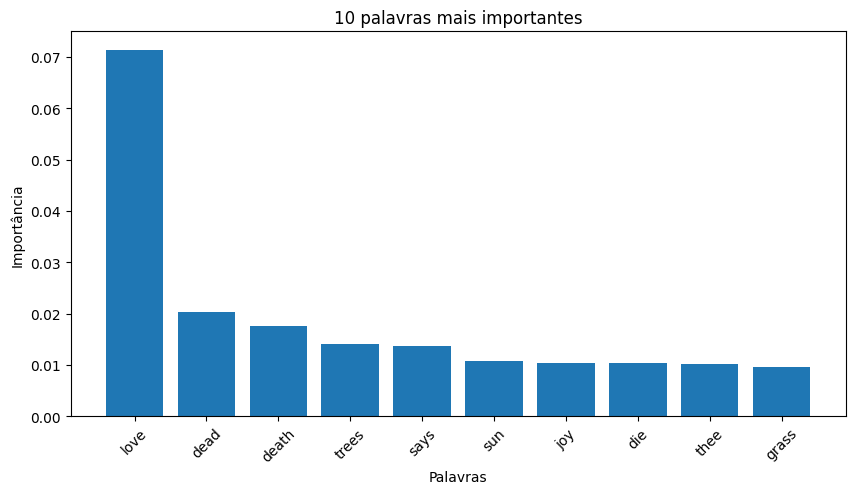

In [43]:
# gerar gráfico
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "word": feature_names,
    "importance": feature_importances
})

top10 = importance_df.sort_values(
    by="importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["word"], top10["importance"])

plt.xlabel("Palavras")
plt.ylabel("Importância")
plt.title("10 palavras mais importantes")

plt.xticks(rotation=45)

plt.show()

In [44]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = random_search.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

# classification report
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.46

Relatório de Classificação:

              precision    recall  f1-score   support

   Affection       0.55      0.45      0.50        75
       Death       0.62      0.34      0.44        83
 Environment       0.45      0.59      0.51        70
       Music       0.33      0.48      0.39        69

    accuracy                           0.46       297
   macro avg       0.49      0.46      0.46       297
weighted avg       0.50      0.46      0.46       297



O relatório de classificação mostrou que o modelo apresentou desempenho moderado na classificação dos gêneros dos poemas, com uma acurácia geral de 46%.

A classe `Affection` teve um dos melhores resultados, com precisão de 0.55 e f1-score de 0.50, indicando que o modelo indetificou bem os padrões relacionados a esse gênero.

A classe `Environment` teve o maior recall (0.59), mostrando que a maioria dos poemas ambientais foi identificada de forma correta.

A classe `Death` apresentou alta precisão (0.62), indicando que quando o modelo prevê esse gênero geralmente acerta, porém como o recall foi baixo (0.34) muitos poemas dessa categoria não foram reconhecidos corretamente.

A classe `Music` teve os menores valores de precisão e f1-score, mostrando maior dificuldade do modelo em diferenciar poemas musicais dos outros gêneros.

No geral, os resultados indicam que existe uma sobreposição de palavras entre os gêneros dos poemas, dificultando a separação das classes apenas com base nas palavras extraídas.

### **3. Questão:**
<font size=3>

Com base no *dataset* de [Performance Acadêmica](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:

1. Importe o *dataset* e defina o atributo `exam_score` como a variável alvo para **regressão**, e os demais atributos como entrada do modelo;

2. Utilize o [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear o pré-processamento [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) dos atributos categóricos com o modelo [`GradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html). **Dica:** para que apenas os atributos categóricos passem pelo pré-processamento, e as demais não, utilize o [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) com a variável `remainder = "passthrough"`;

3. **Escreva** em uma **célula _markdown_** as semelhanças e diferenças entre o modelo *gradient booting* e o *random forest*;

4. Plote o gráfico de barras da importâncias dos atributos e, com base nele, **escreva** em uma **célula _markdown_** um breve relatório sobre quais atributos são mais relevantes e os menos relevantes. Desenvolva uma análise interpretativa do porquê esses atributos se destacam desta forma.

5. Para avaliação do modelo, **imprima na tela** o valores de MSE e $R^2$ entre os dados de predição e teste.


In [45]:
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/student_habits_performance.csv", encoding='latin-1')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [46]:
# definindo variáveis
X = df.drop(columns=['exam_score'])
y = df['exam_score']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (909, 14)
Shape of y: (909,)


In [47]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer

categorical_features = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical_encoder",
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
            categorical_features
        )
    ],
    remainder="passthrough"
)


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

# encadeamento ordinalencoder com o modelo usando pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical_encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

O Gradient Boosting e o Random Forest são modelos baseados em árvores de decisão que utilizam várias árvores para melhorar o desempenho das previsões. Ambos conseguem lidar com relações não lineares nos dados e ajudam a reduzir problemas de uma única árvore, como erros excessivos e overfitting.

A principal diferença está na forma como as árvores são construídas: o Random Forest cria várias árvores independentes em paralelo e combina suas respostas finais, já o Gradient Boosting constrói as árvores em sequência, fazendo com que cada nova árvore tente corrigir os erros das anteriores.

Dessa forma, o Random Forest tende a ser mais robusto e menos sensível a ajustes, enquanto o Gradient Boosting pode alcançar maior precisão, mas exige maior cuidado na escolha dos hiperparâmetros.

In [49]:
from sklearn.model_selection import train_test_split

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# treinamento
pipeline.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical_encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

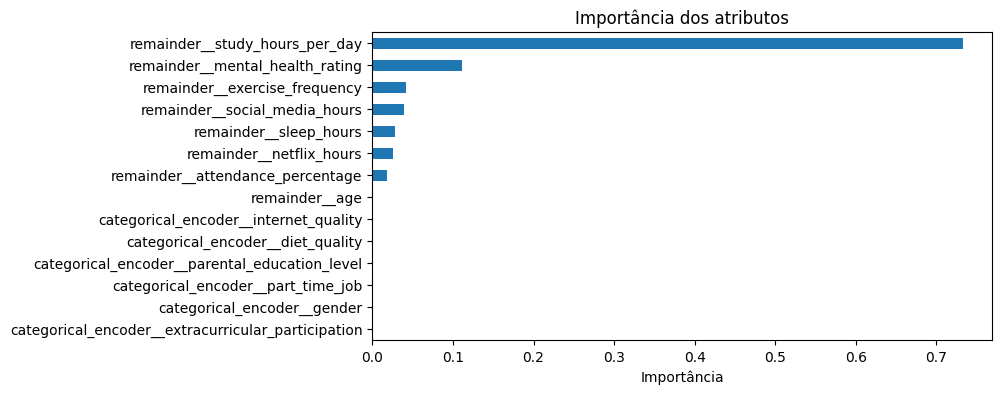

In [50]:
# modelo treinado
model = pipeline.named_steps["model"]

# nomes dos atributos depois da transformação
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = pd.Series(
    model.feature_importances_,
    index=feature_names
)

importances.sort_values(
    ascending=True
).plot(
    kind='barh',
    title='Importância dos atributos',
    figsize=(8,4)
)

plt.xlabel("Importância")
plt.show()

In [51]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MSE: 30.28
R²: 0.89


A partir do gráfico, podemos perceber que o atributo `study_hours_per_day` foi o mais importante, indicando que a quantidade de horas de estudo por dia teve a maior influência nas previsões do modelo, mostrando uma relação forte entre tempo dedicado aos estudos e desempenho acadêmico.

O atributo `mental_health_rating` apareceu em segundo lugar, mostrando que fatores relacionados ao bem-estar mental também podem impactar os resultados dos estudantes.

Em seguida aparecem `exercise_frequency`, `social_media_hours`, `sleep_hours`, `netflix_hours` e `attendance_percentage`, mas com contribuições bem menores.

Os atributos categóricos, como `gender`, `part_time_job`, `parental_education_level`, `diet_quality`, `internet_quality` e `extracurricular_participation`, apresentaram importância nula, ou seja, quase não contribuíram para as decisões do modelo.

Portanto, o modelo encontrou padrões mais fortes em hábitos e comportamentos dos estudantes do que em características categóricas ou pessoais.